# Example Zernike Projection

This notebook demonstrates a way to compute the Zernike coefficients: <br>
Remember that an arbitrary wavefront can be described as a linear combination of Zernike (circular) Polynomials.

\begin{equation}
    W(r,\theta) = \sum_{i=1}^{\infty}a_iZ_i(r,\theta)
\end{equation}

Where $a_i$ = Coefficient and $Z_i(r,\theta)$ is the Zernike Polynomial <br>
As an intuition, the coefficient $a_i$ tells you how much of the abberation mode $Z_i(r,\theta)$ is present within the wavefront $W(r,\theta)$. For example, in the example_zernike_projection.m file from J. Schmidt, an arbitrary wavefront with 3 modes:

$$
    W(r,\theta) = 0.5Z_2(r,\theta) + 0.25Z_4(r,\theta) - 0.6Z_{21}(r,\theta)
$$

What does this mean? This means that the wavefront contains 0 piston, 0.5 amount of $x$ tilt, 0 $y$ tilt, 0.25 amount of defocus, ... ,  -0.6 amount of $y$ pentafoil, ...<br>
Refer to Table 5.2 to look up the different modes.

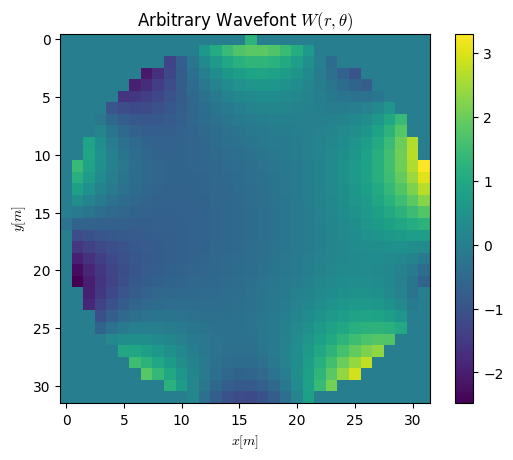

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.aperture_functions import circ
from optprop.transforms import cart2pol
from optprop.zernike import zernike

N = 32
L = 2
delta = L/N
x = np.arange(-N/2,N/2,1) * delta
x,y = np.meshgrid(x,x)
r,theta = cart2pol(x,y)

ap = circ(x,y,2)
z2 = zernike(2,r,theta) * ap
z4 = zernike(4,r,theta) * ap
z21 = zernike(21,r,theta) * ap

W = 0.5 * z2 + 0.25 * z4 - 0.6 * z21

fig,ax = plt.subplots()
im = ax.imshow(W)
fig.colorbar(im)
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title(r"Arbitrary Wavefont $W(r,\theta)$",math_fontfamily='cm')
plt.show()
